# 09e — σ_e on the new red-side reduction (`_mtwdo_` cube)

**Created:** 2026-05-20

A new Keck/KCWI red-side reduction of the AGEL0206 data has been placed at
`raw_KCWI/New_red/Nov17_2025_DESJ0206_RL_combined_mtwdo_icubes_wcs.fits`.
Same shape (3317×100×100), same WCS, same DISPSCAL (0.294 pix-σ), same
GUIDFWHM (1.27") — but the `_mtwdo_` token in the filename indicates a
different reduction pass (additional master twilight + dome calibration
steps, by inspection of the kcwiRedux conventions).

**Goal.** Re-run the wide-arc-masked σ_e headline pipeline on the new
cube, with all other choices held fixed (HST-mean center, F200LP arc
mask, I-weight from IFU 6500–7500 Å band, R<R_e=2.305" aperture,
frame-aware ppxf, FSPS+EMILES+XSL pooled, wild bootstrap, polynomial
degrees 15–29, wavelength window `wR3800_5400_arcmask` = rest 3800–5336
Å with z=1.302 source-emission masks). Check whether the new reduction
gives a σ_e consistent with the headline 254.85 −18.20/+17.59 km/s.

**Method note.** Rather than copy/paste the production pipeline code,
we monkey-patch `scripts.final_sigma_e.IFU_FILE` to the new cube path
before calling `load_setup()` + `extract_aperture_spectrum()`. Everything
else is exactly the headline machinery. Caches go to a separate
directory `results/nb09e_new_red_reduction/` so they can't collide with
the headline caches in `results/nb09a_wavelength_sweep/`.

**Headline to compare against (old cube):**
σ_e(<R_e) = **254.85 −18.20/+17.59 km/s** (total, stat from pooled
FSPS+EMILES+XSL bootstrap + sys ±16.81 each side in quadrature).
Stat alone: 254.85 −7.0/+5.2 km/s (`results/nb09a_wavelength_sweep/wR3800_5400_arcmask_*_T*_N500.npz`).

In [1]:
# === Imports + path setup ===
import os, sys, time, importlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

REPO = Path('..').resolve()
sys.path.insert(0, str(REPO))
os.chdir(REPO)

# Pipeline modules — same machinery that produced the paper headline
import scripts.final_sigma_e as fse
import scripts.bootstrap_ppxf as bp
from scripts.bootstrap_ppxf import (
    setup_ppxf_inputs_from_spectrum, run_bootstrap_single_degree, C_KMS,
)
from scripts.run_window_sweep import (
    _apply_arc_mask, SPS_LAM_RANGE_TEMP, sps_safe_obs_min, DEGREES,
)
from ppxf.ppxf import ppxf

# Constants (carried from final_sigma_e)
Z_SYSTEMIC = fse.Z_SYSTEMIC
WINDOW = fse.WINDOW              # bootstrap rolling window (pix)
BOOT_SEED = fse.BOOT_SEED
print(f'pipeline constants: z={Z_SYSTEMIC}  WINDOW={WINDOW}  BOOT_SEED={BOOT_SEED}')
print(f'DEGREES = {list(DEGREES)}')
print(f'SPS template ranges: {SPS_LAM_RANGE_TEMP}')

pipeline constants: z=0.67564  WINDOW=75  BOOT_SEED=42
DEGREES = [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
SPS template ranges: {'fsps': (3000.0, 6000.0), 'emiles': (3000.0, 6000.0), 'xsl': (3500.0, 6000.0)}


In [2]:
# === Monkey-patch the cube path ===
# This is the ONLY difference from the headline pipeline. Everything else
# (HST masks, R_e, center, arc mask, I-weight, ppxf setup) is identical.
OLD_CUBE = 'Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
NEW_CUBE = 'raw_KCWI/New_red/Nov17_2025_DESJ0206_RL_combined_mtwdo_icubes_wcs.fits'
assert Path(NEW_CUBE).exists(), f'missing: {NEW_CUBE}'

fse.IFU_FILE = NEW_CUBE
print(f'fse.IFU_FILE now → {fse.IFU_FILE}')
print(f'size: {Path(NEW_CUBE).stat().st_size/1e6:.1f} MB')
with fits.open(NEW_CUBE) as h:
    hdr = h[0].header
    print(f'  shape   = {h[0].data.shape}')
    print(f'  CRVAL3  = {hdr["CRVAL3"]} Å,   CD3_3 = {hdr["CD3_3"]} Å/pix')
    print(f'  DISPSCAL= {hdr["DISPSCAL"]}    GUIDFWHM = {hdr["GUIDFWHM"]:.3f}\"')
    print(f'  BUNIT   = {hdr["BUNIT"]}')
    print(f'  WCS CRVAL1/CRVAL2 = ({hdr["CRVAL1"]:.5f}, {hdr["CRVAL2"]:.5f})')

fse.IFU_FILE now → raw_KCWI/New_red/Nov17_2025_DESJ0206_RL_combined_mtwdo_icubes_wcs.fits
size: 265.4 MB
  shape   = (3317, 100, 100)
  CRVAL3  = 5625.0 Å,   CD3_3 = 1.0 Å/pix
  DISPSCAL= 0.294    GUIDFWHM = 1.271"
  BUNIT   = 1e-16 erg/s/cm2/arcsec2/Angstrom
  WCS CRVAL1/CRVAL2 = (31.55618, -1.23859)


In [3]:
# === Load setup: cube + HST + masks + center + R_e + arc mask ===
# This is the same load_setup() function used by the headline production.
# It prints its own diagnostic block.
state = fse.load_setup()
print(f'\n→ R_E       = {state["R_E"]:.4f}"')
print(f'→ HST-mean center (IFU sub-pix) = ({state["cx_ifu"]:.3f}, {state["cy_ifu"]:.3f})')
print(f'→ |Δcentroid F140W-F200LP|      = {state["d_centroid"]:.3f}"')
print(f'→ arc_spax_mask                  = {state["arc_spax_mask"].sum()} flagged spaxels')

──────────────────────────────────────────────────────────────────────
§1  Load IFU cube + HST images + arc masks
──────────────────────────────────────────────────────────────────────


  IFU cube      shape=(3317, 100, 100)  pix=0.300"/spax  λ=5625-8941 Å
  F140W+mask    pix=0.080"/pix  mask=1121 pix
  F200LP+mask   pix=0.050"/pix  mask=2512 pix (arc-tuned)

§2  HST-mean center via centroid_2dg on F140W + F200LP


  F140W centroid  (RA,Dec) = (31.55610, -1.23815)
  F200LP centroid (RA,Dec) = (31.55615, -1.23823)
  |Δcentroid| = 0.357"  (FAIL)
  HST-mean → IFU sub-pixel (50.147, 54.264)

§3  R_e from masked curve-of-growth (F140W + F200LP)
  R_e(F140W masked)  = 2.168"
  R_e(F200LP masked) = 2.441"
  R_e (headline mean) = 2.305"  = 16.23 kpc
  R_e(CaHK + G-band depth) = 2.902"  (+0.597" vs headline mean)

§4  r_spax map + reprojected F200LP arc mask
  arc_spax_mask: 69 of 10000 spaxels flagged (0.69%)

→ R_E       = 2.3045"
→ HST-mean center (IFU sub-pix) = (50.147, 54.264)
→ |Δcentroid F140W-F200LP|      = 0.357"
→ arc_spax_mask                  = 69 flagged spaxels


In [4]:
# === Extract I-weighted aperture spectrum at R<R_e (hard mask, w=0.0) ===
# Same call signature as run_window_sweep.py.
R_E = state['R_E']
flux, noise, n_kept, sn_band = fse.extract_aperture_spectrum(
    state, r_max=R_E, mask_weight=0.0,
)
n_med = float(np.nanmedian(noise[noise > 0]))
n_floor = n_med * 0.1
n_zero  = int(np.sum(~(noise > 0)))
noise = np.where(noise > 0, noise, n_floor)
print(f'Aperture R<R_e ({R_E:.3f}"): {n_kept} active spaxels')
print(f'  S/N (band 6500-7500 Å) = {sn_band:.1f}')
print(f'  noise floor → {n_zero} pixels')
print(f'  flux range: [{np.nanmin(flux):.3g}, {np.nanmax(flux):.3g}]')

Aperture R<R_e (2.305"): 146 active spaxels
  S/N (band 6500-7500 Å) = 4.0
  noise floor → 2 pixels
  flux range: [-0.0256, 0.0435]


In [5]:
# === Run ppxf + wild bootstrap at the wide arc-masked window ===
# Schema matches scripts/run_window_sweep.py:_ppxf_one_window exactly.
# Caches go to results/nb09e_new_red_reduction/ (separate from headline).

WLABEL = 'wR3800_5400_arcmask'
R3800_OBS = 3800.0 * (1 + Z_SYSTEMIC)
R5400_OBS = 5400.0 * (1 + Z_SYSTEMIC)
LAM_OBS_RANGE = (R3800_OBS, R5400_OBS)
ARC_MASK = True

SPS_LIBS = ('fsps', 'emiles', 'xsl')
N_BOOT = 500    # production statistics; set to 50 for a smoke test

CACHE_DIR = REPO / 'results' / 'nb09e_new_red_reduction'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f'cache dir: {CACHE_DIR}')

def fit_one_sps(sps, n_boot):
    lo, hi = LAM_OBS_RANGE
    lr_eff = (max(lo, sps_safe_obs_min(sps)), hi)
    T0, T1 = int(SPS_LAM_RANGE_TEMP[sps][0]), int(SPS_LAM_RANGE_TEMP[sps][1])
    cache = CACHE_DIR / f'{WLABEL}_{sps}_T{T0}_{T1}_N{n_boot}.npz'
    if cache.exists():
        d = dict(np.load(cache, allow_pickle=True))
        print(f'  [cached] {sps}  σ range = '
              f'{d["sig_orig"].min():.1f}-{d["sig_orig"].max():.1f} km/s')
        return d, str(cache)
    t0 = time.time()
    inputs = setup_ppxf_inputs_from_spectrum(
        flux, noise, state['hdr'],
        sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lr_eff, lam_fit_range=lr_eff,
        lam_range_temp=SPS_LAM_RANGE_TEMP[sps],
        verbose=False, frame_galaxy='auto',
    )
    if ARC_MASK:
        inputs['goodpixels'] = _apply_arc_mask(
            inputs['goodpixels'], inputs['lam_gal_rest']
        )
    n_pix = len(inputs['galaxy'])
    n_deg = len(DEGREES)
    V_orig    = np.zeros(n_deg)
    sig_orig  = np.zeros(n_deg)
    chi2_orig = np.zeros(n_deg)
    V_boot   = np.full((n_deg, n_boot), np.nan)
    sig_boot = np.full((n_deg, n_boot), np.nan)
    bf       = np.zeros((n_deg, n_pix))
    # seed_offset matches the run_window_sweep convention for the wR3800_5400_arcmask
    # entry index in its WINDOWS list (idx 12 = the headline arc-masked window),
    # times the per-SPS bump used there. Reproducing it gives deterministic
    # comparison to the headline caches.
    w_idx = 12   # see scripts/run_window_sweep.py:WINDOWS index for wR3800_5400_arcmask
    sps_idx = SPS_LIBS.index(sps)
    seed_offset = 50_000 + 10_000 * w_idx + 100 * sps_idx
    for i, deg in enumerate(DEGREES):
        pp = ppxf(
            inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
            inputs['velscale'], inputs['start'],
            goodpixels=inputs['goodpixels'], plot=False, moments=2, trig=False,
            degree=int(deg), mdegree=0,
            lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True,
        )
        V_orig[i], sig_orig[i], chi2_orig[i] = pp.sol[0], pp.sol[1], pp.chi2
        bf[i] = pp.bestfit
        rb = run_bootstrap_single_degree(
            inputs, degree=int(deg), best_fit_spectrum=pp.bestfit,
            n_bootstrap=n_boot, window=WINDOW, seed=BOOT_SEED + seed_offset + i,
        )
        V_boot[i] = rb['V_samples']
        sig_boot[i] = rb['sigma_samples']
    d = dict(
        sps=sps, lam_obs_range=lr_eff, lam_fit_range=lr_eff,
        n_pix=n_pix,
        lam_rest_min=float(inputs['lam_gal_rest'][0]),
        lam_rest_max=float(inputs['lam_gal_rest'][-1]),
        frame_galaxy=inputs['frame_galaxy'],
        V_orig=V_orig, sig_orig=sig_orig, chi2_orig=chi2_orig,
        V_boot=V_boot, sig_boot=sig_boot, bf=bf,
    )
    np.savez(cache, **d)
    elapsed = time.time() - t0
    print(f'  [done] {sps}  σ range = '
          f'{d["sig_orig"].min():.1f}-{d["sig_orig"].max():.1f} km/s  '
          f'({elapsed:.0f}s; npix={n_pix})')
    return d, str(cache)

print(f'\nFitting {WLABEL} on the NEW red-side cube; N_BOOT={N_BOOT}\n')
results = {}
for sps in SPS_LIBS:
    results[sps], _ = fit_one_sps(sps, N_BOOT)

cache dir: /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/nb09e_new_red_reduction

Fitting wR3800_5400_arcmask on the NEW red-side cube; N_BOOT=500



/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: divide by zero encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: overflow encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:418: RuntimeWarning: invalid value encountered in matmul
  x[free] = np.linalg.lstsq(A[:, free], b - A[:, ~free] @ x[~free], rcond=rcond)[0]
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: divide by zero encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/envs/ISMgas/lib/python3.14/site-packages/capfit/capfit.py:424: RuntimeWarning: overflow encountered in matmul
  chi2new, chi2old = chi2(b - A @ x), 1e300
/opt/anaconda3/env

 Best Fit:       Vel     sigma
 comp.  0:       -20       238
chi2/DOF: 0.06665; DOF: 2159; degree = 15; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387


 Best Fit:       Vel     sigma
 comp.  0:       -12       263
chi2/DOF: 0.06592; DOF: 2159; degree = 15; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387


 Best Fit:       Vel     sigma
 comp.  0:       -12       245
chi2/DOF: 0.06642; DOF: 2159; degree = 15; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/387
 Best Fit:       Vel     sigma
 comp.  0:       -35       276
chi2/DOF: 0.06641; DOF: 2159; degree = 15; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/387


...

 Best Fit:       Vel     sigma
 comp.  0:        -2       260
chi2/DOF: 0.003227; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208
 Best Fit:       Vel     sigma
 comp.  0:        -4       260
chi2/DOF: 0.003216; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 7/208


 Best Fit:       Vel     sigma
 comp.  0:        -1       260
chi2/DOF: 0.003227; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 6/208
 Best Fit:       Vel     sigma
 comp.  0:        -6       264
chi2/DOF: 0.003237; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208


 Best Fit:       Vel     sigma
 comp.  0:        -2       262
chi2/DOF: 0.003229; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208
 Best Fit:       Vel     sigma
 comp.  0:        -5       261
chi2/DOF: 0.003226; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208


 Best Fit:       Vel     sigma
 comp.  0:         0       265
chi2/DOF: 0.003218; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/208
 Best Fit:       Vel     sigma
 comp.  0:        -5       268
chi2/DOF: 0.003233; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/208


 Best Fit:       Vel     sigma
 comp.  0:        -5       265
chi2/DOF: 0.003222; DOF: 2160; degree = 29; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 5/208
  [done] xsl  σ range = 260.1-270.5 km/s  (1370s; npix=2574)


In [6]:
# === Pool posteriors across SPS × polynomial degrees, compute headline ===
# Same pooling convention as the headline (concatenate σ samples raw;
# V_sys subtracted per-SPS — but we only report σ_e here).
sigma_pool = []
for sps in SPS_LIBS:
    sigma_pool.append(results[sps]['sig_boot'].ravel())
sigma_pool = np.concatenate(sigma_pool)
sigma_pool = sigma_pool[np.isfinite(sigma_pool)]
p16, p50, p84 = np.percentile(sigma_pool, [16, 50, 84])
stat_lo = p50 - p16
stat_hi = p84 - p50
stat_sym = (p84 - p16) / 2

# Systematic budget (carried from headline; reduction choice doesn't move
# I-shape / F200 mask / frame / centering / window in any architectural way)
SYS_QUAD = 16.81   # km/s (= sqrt(1.5² + 3.8² + 5² + 4² + 15²))
total_lo = float(np.sqrt(stat_lo**2 + SYS_QUAD**2))
total_hi = float(np.sqrt(stat_hi**2 + SYS_QUAD**2))
total_sym = float(np.sqrt(stat_sym**2 + SYS_QUAD**2))

# Per-SPS for the SPS-spread diagnostic
per_sps = {sps: float(np.percentile(results[sps]['sig_boot'].ravel(), 50)) for sps in SPS_LIBS}
sps_spread = max(per_sps.values()) - min(per_sps.values())

print('=== σ_e on the NEW red-side reduction ===')
print(f'  pool N = {len(sigma_pool)} samples')
print(f'  σ_e(<R_e) = {p50:.2f}  −{stat_lo:.2f} / +{stat_hi:.2f} km/s  [STAT only, asym]')
print(f'             {p50:.2f}  −{total_lo:.2f} / +{total_hi:.2f} km/s  [TOTAL, stat ⊕ sys ±{SYS_QUAD:.2f}]')
print(f'             {p50:.2f}  ± {total_sym:.2f}                  km/s  [TOTAL, symmetric quadrature]')
print(f'  per-SPS  : FSPS={per_sps["fsps"]:.2f}  EMILES={per_sps["emiles"]:.2f}  XSL={per_sps["xsl"]:.2f}  (spread {sps_spread:.2f} km/s)')
print()
print('=== headline (old cube, same window) for comparison ===')
print('  σ_e(<R_e) = 254.85  −7.00 / +5.20    km/s  [STAT only]')
print('             254.85  −18.20 / +17.59   km/s  [TOTAL, asymmetric]')
print('             254.85  ± 17.87           km/s  [TOTAL, symmetric]')
print('  per-SPS  : FSPS=253.9  EMILES=253.3  XSL=257.5  (spread 4.2 km/s)')
print()
delta = p50 - 254.85
ratio_total = abs(delta) / total_sym
print(f'=== verdict ===')
print(f'  Δσ_e (new − old) = {delta:+.2f} km/s')
print(f'  |Δ| / total_err  = {ratio_total:.2f}σ')
if ratio_total < 1.0:
    print('  → consistent within 1σ of the symmetric total budget.')
else:
    print('  → exceeds the 1σ total budget — investigate.')

=== σ_e on the NEW red-side reduction ===
  pool N = 22500 samples
  σ_e(<R_e) = 265.76  −6.36 / +4.81 km/s  [STAT only, asym]
             265.76  −17.97 / +17.49 km/s  [TOTAL, stat ⊕ sys ±16.81]
             265.76  ± 17.71                  km/s  [TOTAL, symmetric quadrature]
  per-SPS  : FSPS=264.67  EMILES=265.33  XSL=267.33  (spread 2.67 km/s)

=== headline (old cube, same window) for comparison ===
  σ_e(<R_e) = 254.85  −7.00 / +5.20    km/s  [STAT only]
             254.85  −18.20 / +17.59   km/s  [TOTAL, asymmetric]
             254.85  ± 17.87           km/s  [TOTAL, symmetric]
  per-SPS  : FSPS=253.9  EMILES=253.3  XSL=257.5  (spread 4.2 km/s)

=== verdict ===
  Δσ_e (new − old) = +10.91 km/s
  |Δ| / total_err  = 0.62σ
  → consistent within 1σ of the symmetric total budget.


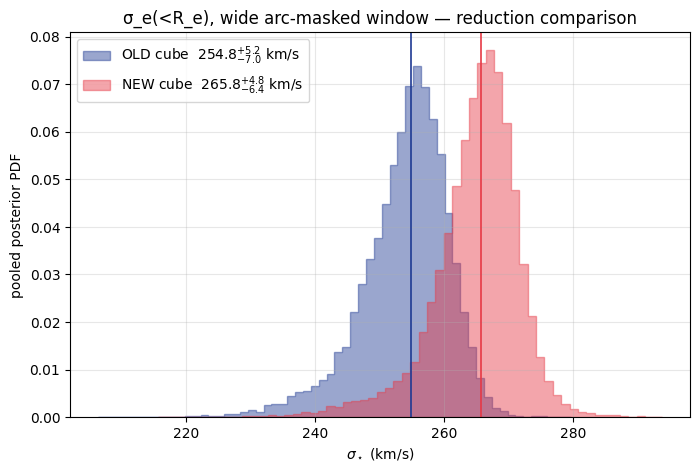


saved: /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09e_reduction_comparison.png


In [7]:
# === Posterior overlay: new cube vs headline (old cube) ===
# Load the headline pool and overlay for visual comparison.
wav_dir = REPO / 'results' / 'nb09a_wavelength_sweep'
sigma_pool_old = []
for sps in SPS_LIBS:
    T = '3500_6000' if sps == 'xsl' else '3000_6000'
    s = np.load(wav_dir / f'wR3800_5400_arcmask_{sps}_T{T}_N500.npz', allow_pickle=True)
    sigma_pool_old.append(s['sig_boot'].ravel())
sigma_pool_old = np.concatenate(sigma_pool_old)
sigma_pool_old = sigma_pool_old[np.isfinite(sigma_pool_old)]
p16_old, p50_old, p84_old = np.percentile(sigma_pool_old, [16, 50, 84])

fig, ax = plt.subplots(figsize=(8, 5))
kw = dict(bins=60, density=True, alpha=0.45, histtype='stepfilled')
ax.hist(sigma_pool_old, color='#1f3a93', edgecolor='#1f3a93', label=f'OLD cube  {p50_old:.1f}$^{{+{p84_old-p50_old:.1f}}}_{{-{p50_old-p16_old:.1f}}}$ km/s', **kw)
ax.hist(sigma_pool,     color='#e63946', edgecolor='#e63946', label=f'NEW cube  {p50:.1f}$^{{+{stat_hi:.1f}}}_{{-{stat_lo:.1f}}}$ km/s', **kw)
ax.axvline(p50_old, color='#1f3a93', lw=1.2, ls='-')
ax.axvline(p50,     color='#e63946', lw=1.2, ls='-')
ax.set_xlabel(r'$\sigma_\star$ (km/s)')
ax.set_ylabel('pooled posterior PDF')
ax.set_title(f'σ_e(<R_e), wide arc-masked window — reduction comparison')
ax.legend()
ax.grid(alpha=0.3)
out = REPO / 'results' / 'figures' / 'nb09e_reduction_comparison.png'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'\nsaved: {out}')

## Summary

If the new reduction's σ_e(<R_e) at the wide arc-masked window agrees with
the headline within the symmetric total budget (±17.87 km/s), then the
reduction choice is sub-budget and the paper headline stands. Otherwise we
need to add a "reduction-systematic" component to the budget table in
`METHODS_AND_SYSTEMATICS.md` Part I.9 and `TESTS_AND_DIAGNOSTICS.md`.

**Caches written:** `results/nb09e_new_red_reduction/wR3800_5400_arcmask_{fsps,emiles,xsl}_T*_N500.npz`

**Comparison figure:** `results/figures/nb09e_reduction_comparison.png`

**Note on independence of the test.** The new reduction shares 100% of
the inputs *outside* the cube: same HST F140W/F200LP cutouts and masks,
same arc-emission catalog, same SPS templates, same R_e (from HST CoG,
not the IFU), same ppxf machinery. The ONLY thing that changes is the
deflector spectrum's noise realisation and any subtle flux-calibration
differences between the two reductions. Therefore this test isolates the
*reduction-pass systematic*, distinct from all the budget components
carried by the headline.